정형 데이터(structured data): 어떤 구조로 되어있는 데이터. csv나 데이터베이스, 엑셀에 저장하기 쉽다.

비정형 데이터(unstructured data): 데이터베이스나 엑셀로 표현하기 어려운 것들. 텍스트 데이터, 사진 음악 등.

### 앙상블 학습(ensemble learning)
정형 데이터를 다루는 데 가장 뛰어난 성과를 내는 알고리즘. 대부분 결정 트리를 기반으로 만들어져 있다. 

그렇다면 비정형 데이터의 알고리즘은?

: 규칙성을 찾기 어려워 전통적인 머신러닝 방법으로는 모델을 만들기 까다롭다.

: '신경망 알고리즘'을 사용

### 랜덤 포레스트(Ranfom Forest)
결정 트리를 랜덤하게 만들어 결정 트리(나무)의 **숲**을 만든다. 그리고 각 결정 트리의 예측을 사용해 최종 예측을 만든다.

* 각 트리를 훈련하기 위한 데이터를 랜덤하게 만든다: **부트스트랩 샘플**. (중복을 허용해서 랜덤하게 샘플을 추출)

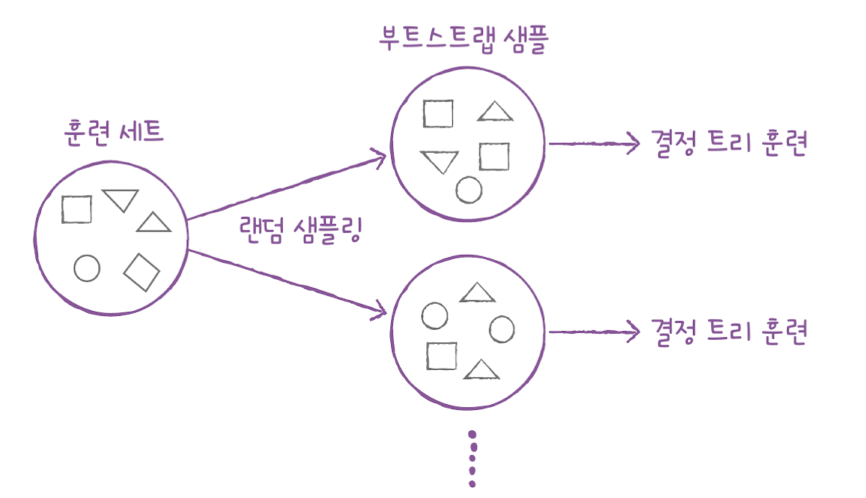

* 각 노드를 분할할 때 전체 특성 중에서 일부 특성을 무작위로 고른 다음 이 중에서 최선의 분할을 찾는다. 

RandomForestClassifier: 분류 모델. 전체 특성 개수의 제곱근만큼의 특성 선택.

RandomForestRegressor: 회귀 모델. 전체 특성을 사용.

* 기본적으로 100개의 결정 트리를 이런 방식으로 훈련한 뒤, 분류일 때는 각 트리의 클래스별 확률을 평균하여 가장 높은 확률을 가진 클래스를 예측으로 삼는다. 회귀일 때는 단순히 각 트리의 예측을 평균한다.

랜덤 포레스트는 랜덤하게 선택한 샘플과 특성을 사용 

-> 훈련세트에 과대적합되는 것을 막아주고, 검증/테스트 세트에서 안정적인 성능 얻을 수 있다.

In [2]:
# 화이트 와인 분류 문제에 랜덤 포레스트 적용
# 데이터 불러오고 훈련/테스트 세트로 나누기
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
wine = pd.read_csv('https://bit.ly/wine_csv_data')

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42)

In [3]:
# 교차 검증 수행
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier

# n_jobs를 -1로 지정하여 모든 CPU 코어 사용
# return_train_score를 True로 지정하여 검증 점수뿐만 아니라 훈련 세트에 대한 점수도 같이 반환
rf = RandomForestClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(rf, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9973541965122431 0.8905151032797809


훈련세트에 과대적합된 것 같다.

랜덤 포레스트는 결정 트리의 앙상블이기 때문에 DecisionTreeClassifier가 제공하는 중요한 매개변수를 모두 제공한다

: criterion, max_depth, max_features, min_samples_split, min_impurity_decrease, min_samples_leaf 등

또한 결정 트리의 큰 장점 중 하나인 **특성 중요도**를 계산한다. (각 결정 트리의 특성 중요도를 취합한 것)

In [4]:
# 앞의 모델을 훈련세트에 훈련한 후 특성 중요도 출력
rf.fit(train_input, train_target)
print(rf.feature_importances_)

[0.23167441 0.50039841 0.26792718]


앞에서 결정 트리 내용에서 특성 중요도: [0.12345626, 0.86862934, 0.0079144]

랜덤 포레스트에서 당도의 중요도 감소하고 알코올 도수/pH 특성의 중요도가 상승했다.

-> 핸덤 포레스트는 특성의 일부를 랜덤하게 선택하여 결정 트리를 훈련하기 때문에, 하나의 특성에 과도하게 집중하지 않고 좀 더 많은 특성이 훈련에 기여할 기회를 얻는다.

이를 통해 과대 적합을 줄이고 일반화 성능 높이는 데 도움이 된다.

***

RandomForestClassifier에는 자체적으로 모델을 평가하는 점수를 얻을 수 있다.
* OOB(out of bag) 샘플: 부트스트랩 샘플에 포함되지 않고 남는 샘플

남는 샘플을 사용하여 부트스트랩 샘플로 훈련한 결정 트리를 평가할 수 있다.

In [5]:
# OOB 점수 출력하기
rf = RandomForestClassifier(oob_score=True, n_jobs=-1, random_state=42)
rf.fit(train_input, train_target)
print(rf.oob_score_)

0.8934000384837406


교차검증에서 얻은 점수와 매우 비슷한 결과.

OOB 점수를 사용하면 교차 검증을 대신할 수 있어서 결과적으로 훈련 세트에 더 많은 샘플을 사용할 수 있다.

### 엑스트라 트리(Extra Trees)
: 기본적으로 100개의 결정 트리를 훈련. 결정 트리가 제공하는 대부분의 매개변수 지원. 전체 특성 중에 일부 특성을 랜덤하게 선택하여 노드를 분할하는 데 사용.

차이점

* 부트스트랩 샘플을 사용하지 않는다 -> 결정 트리를 만들 때 전체 훈련 세트를 사용한다.
* 노드를 분할할 때 가장 좋은 분할을 찾는 것이 아니라 무작위로 분할한다.
* splitter = 'random'인 결정 트리.

-> 하나의 결정 트리에서 특성을 무작위로 분할한다면 성능이 낮아질 것. 하지만 많은 트리를 앙상블 하기 때문에 과대적합을 막고 검증 세트의 점수를 높이는 효과.

In [6]:
# 엑스트라 트리 모델의 교차 검증 점수 확인
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(n_jobs=-1, random_state=42)
scores = cross_validate(et, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9974503966084433 0.8887848893166506


랜덤 포레스트와 비슷한 결과. 이 데이터의 경우 특성이 많지 않아 두 모델의 차이가 크지 않다. 

보통은 엑스트라 트리가 무작위성이 좀 더 크기 때문에 랜덤 포레스트보다 더 많은 트리를 훈련해야 한다. 하지만 랜덤하게 노드를 분할하기 때문에 빠른 계산 속도.

In [7]:
# 엑스트라 트리에 의한 특성 중요도 확인
et.fit(train_input, train_target)
print(et.feature_importances_)

[0.20183568 0.52242907 0.27573525]


엑스트라 트리도 결정 트리보다 당도에 대한 의존성이 작게 나타난다.

### 그레이디언트 부스팅(Gradient boosting)
깊이가 얕은 결정 트리를 사용, 이전 트리의 오차를 보완하는 방식으로 앙상블 한다.

기본적으로 깊이가 3인 결정 트리를 100개 사용. 

과대적합에 강하고, 일반적으로 높은 일반화 성능을 기대할 수 있다.

* 경사하강법을 사용하여 트리를 앙상블에 추가한다. (분류-로지스틱 회귀, 회귀-평균 제곱 오차 함수 사용)

* 결정 트리를 계속 추가하면서 가장 낮은 곳을 찾아 이동한다. 낮은 곳으로 조금씩 천천히 이동해야 하므로 깊이가 얕은 트리를 사용한다. 학습률 매개변수로 속도를 조절한다.

In [8]:
# 그래디언트 부스팅으로 와인 데이터셋의 교차 검증 점수 확인하기
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42)
scores = cross_validate(gb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8881086892152563 0.8720430147331015


과대적합이 거의 되지 않는다! 그레이디언트 부스팅은 결정 트리의 개수를 늘려도 과대적합에 매우 강하다.

In [9]:
# 학습률 증가시키고 트리 개수 늘려서 학습
gb = GradientBoostingClassifier(n_estimators=500, learning_rate=0.2,
                                random_state=42)
scores = cross_validate(gb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9464595437171814 0.8780082549788999


결정 트리 개수를 500개로 5배 늘렸지만 과대적합을 잘 억제하고 있다.

learning_rate의 기본값은 0.1

In [10]:
# 그레이디언트 부스팅의 특성 중요도 확인
gb.fit(train_input, train_target)
print(gb.feature_importances_)

[0.15887763 0.6799705  0.16115187]


랜덤 포레스트보다 일부 특성(당도)에 더 집중한다.

* 'subsample' 매개변수

기본값은 1.0으로 전체 훈련 세트를 사용한다. 

1보다 크면 훈련 세트의 일부를 사용. 이는 경사 하강법 단계마다 일부 샘플을 랜덤하게 선택하여 진행하는 확률적/미니배치 경사 하강법과 비슷하다.

일반적으로 그레이디언트 부스팅이 랜덤 포레스트보다 조금 더 높은 성능. 하지만 순서대로 트리를 추가하기 때문에 훈련 속도가 느리다. (n_jobs 매개변수가 없다)

### 히스토그램 기반 그레이디언트 부스팅(Histogram-based Gradient Boosting)

입력 특성을 256개의 구간으로 나눈다 -> 노드를 분할할 때 최적의 분할을 매우 빠르게 찾을 수 있다.

256개의 구간 중에서 하나를 떼어 놓고 누락된 값을 위해 사용한다. 따라서 입력에 누락된 특성이 있어도 이를 따로 전처리할 필요가 없다.

In [12]:
# 와인 데이터에 HistGradientBoostingClassifier 클래스 적용
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)
scores = cross_validate(hgb, train_input, train_target,
                        return_train_score=True)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.9321723946453317 0.8801241948619236


과대적합을 잘 억제하면서 그레이디언트 부스팅보다 조금 더 높은 성능.

In [13]:
# 히스토그램 기반 그레이디언트 부스팅의 특성 중요도 확인
from sklearn.inspection import permutation_importance

hgb.fit(train_input, train_target)
result = permutation_importance(hgb, train_input, train_target,
                                n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.08876275 0.23438522 0.08027708]


permutation_importance() 함수는 특성을 하나씩 랜덤하게 섞어서 모델의 성능이 변화하는지 관찰, 어떤 특성이 중요한지를 계산한다.

n_repeats: 랜덤하게 섞을 횟수를 지정(기본값 5)

평균을 출력해보면 랜덤 포레스트와 비슷한 비율임을 알 수 있다.

In [14]:
# 테스트 세트에서의 특성 중요도 확인
result = permutation_importance(hgb, test_input, test_target,
                                n_repeats=10, random_state=42, n_jobs=-1)
print(result.importances_mean)

[0.05969231 0.20238462 0.049     ]


그레이디언트 부스팅과 비슷하게 조금 더 당도에 집중하고 있다.

In [15]:
# 테스트 세트에서의 성능 최종 확인
hgb.score(test_input, test_target)

0.8723076923076923

약 87%의 정확도. 단일 결정 트리보다 좋은 결과(86%였음)

사이킷런 말고도 그레이디언트 부스팅 알고리즘을 구현한 라이브러리

#### 1️⃣ XGBoost 

In [16]:
from xgboost import XGBRFClassifier

xgb = XGBRFClassifier(tree_method='hist', random_state=42)
scores = cross_validate(xgb, train_input, train_target,
                        return_train_score=True)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.8835388838034979 0.8685785148441549


#### 2️⃣ LightGBM

In [18]:
from lightgbm import LGBMClassifier
lgb = LGBMClassifier(random_state=42)
scores = cross_validate(lgb, train_input, train_target,
                        return_train_score=True, n_jobs=-1)
print(np.mean(scores['train_score']), np.mean(scores['test_score']))

0.935828414851749 0.8801251203079884


지금까지 입력과 타깃이 준비된 **지도 학습(supervised learning)**을 보았다.